In [44]:
# Aumento de datos
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

# crea el data set
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.25,
    height_shift_range=0.25,
    shear_range=0.15,
    zoom_range=[0.5, 1.5],
    validation_split=0.2
)

# generar set para entrenamiento y pruebas
data_gen_entrenamiento = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                                     batch_size=32,subset='training', shuffle=True,class_mode='binary')
data_gen_pruebas = datagen.flow_from_directory('dataset/', target_size=(160, 160),
                                               batch_size=32, subset='validation', shuffle=True,class_mode='binary')

Found 80 images belonging to 2 classes.
Found 20 images belonging to 2 classes.


In [45]:
import tensorflow as tf

In [46]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16, (3,3), activation='relu', input_shape=(160,160,3)),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(32, (3,3), activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(64, (3,3), activation='relu'),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(1, activation='sigmoid'), #tf.keras.layers.Dense(num_clases, activation='softmax')
])

In [47]:
model.compile(loss='binary_crossentropy',
              optimizer=tf.keras.optimizers.RMSprop(learning_rate=0.001),
              metrics=['acc'])
model_fit = model.fit(data_gen_entrenamiento,
                      steps_per_epoch=3,
                      epochs=30,
                      validation_data = data_gen_pruebas
)

/home/rodrigo/Documentos/Prog/Python/entV/lib/python3.12/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 770ms/step - acc: 0.5146 - loss: 0.8640 - val_acc: 0.5000 - val_loss: 0.7166
Epoch 2/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 450ms/step - acc: 0.5344 - loss: 0.6802 - val_acc: 0.8000 - val_loss: 0.6380
Epoch 3/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 523ms/step - acc: 0.7302 - loss: 0.6216 - val_acc: 0.5500 - val_loss: 0.5929
Epoch 4/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 423ms/step - acc: 0.7000 - loss: 0.5129 - val_acc: 0.6500 - val_loss: 0.8115
Epoch 5/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 444ms/step - acc: 0.7750 - loss: 0.5362 - val_acc: 0.7500 - val_loss: 0.7041
Epoch 6/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 459ms/step - acc: 0.7977 - loss: 0.4154 - val_acc: 0.6500 - val_loss: 0.4843
Epoch 7/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 462ms/step - acc: 0.8508 - loss: 0.3780 - val_acc: 1.0000 - val_loss: 0.2514
Epoch 8/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 452ms/step - acc: 0.9570 - loss: 0.2402 - val_acc: 0.6500 - val_loss: 0.8606
Epoch 9/30
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 448ms/step - acc: 0.7911 - loss: 

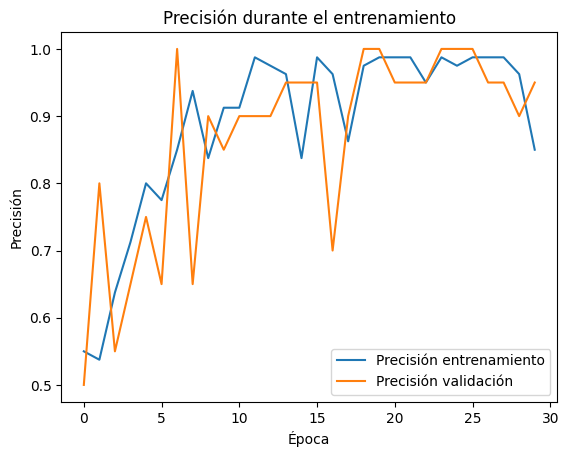

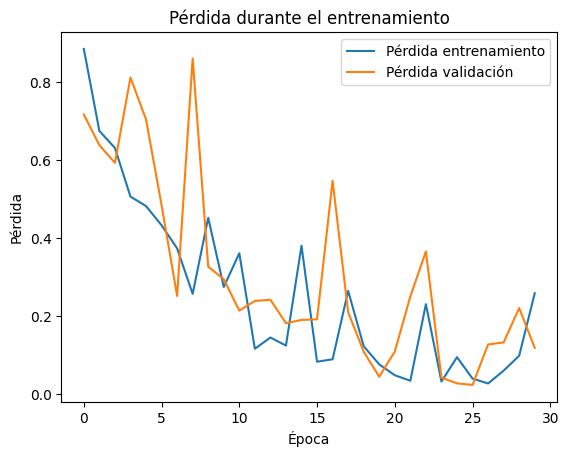

In [48]:
import matplotlib.pyplot as plt

# Graficar precisión
plt.plot(model_fit.history['acc'], label='Precisión entrenamiento')
plt.plot(model_fit.history['val_acc'], label='Precisión validación')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.title('Precisión durante el entrenamiento')
plt.show()

# Graficar pérdida
plt.plot(model_fit.history['loss'], label='Pérdida entrenamiento')
plt.plot(model_fit.history['val_loss'], label='Pérdida validación')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.title('Pérdida durante el entrenamiento')
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np

# Ruta de la imagen a probar
img_path = 'dataset/desc/Abdullah_Ahmad_Badawi_0001.jpg'  # Cambia por tu imagen
#img_path = 'dataset/rodrigo/rostro_50.jpg'  # Cambia por tu imagen

# Cargar y preprocesar la imagen
img = image.load_img(img_path, target_size=(160, 160))
img_array = image.img_to_array(img)
img_array = img_array / 255.0  # Normaliza igual que en el entrenamiento
img_array = np.expand_dims(img_array, axis=0)  # Añade dimensión batch
pred = model.predict(img_array)
print(f"Predicción bruta: {pred[0][0]}")

# Umbral para decidir si es "yo" o "no yo"
if pred[0][0] > 0.8:
    print("¡Es tu rostro!")
else:
    print("No es tu rostro.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Predicción bruta: 0.011559647507965565
No es tu rostro.


In [57]:
#guarda modelo
model.export('modelo_exportado')

INFO:tensorflow:Assets written to: modelo_exportado/assets


INFO:tensorflow:Assets written to: modelo_exportado/assets


Saved artifact at 'modelo_exportado'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 160, 160, 3), dtype=tf.float32, name='keras_tensor_70')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  129190808102928: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808526416: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808532752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808531024: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808531408: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808532560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808531984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808532176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808534480: TensorSpec(shape=(), dtype=tf.resource, name=None)
  129190808526992: TensorSpec(shape=(), dtype=tf.resource, name=None)


In [59]:
# Convierte directamente desde la carpeta SavedModel
converter = tf.lite.TFLiteConverter.from_saved_model('modelo_exportado')
tflite_model = converter.convert()

# Guarda el modelo TFLite
with open('modelo_exportado/modelo.tflite', 'wb') as f:
    f.write(tflite_model)

W0000 00:00:1751259380.944561   21889 tf_tfl_flatbuffer_helpers.cc:365] Ignored output_format.
W0000 00:00:1751259380.948084   21889 tf_tfl_flatbuffer_helpers.cc:368] Ignored drop_control_dependency.
2025-06-29 22:56:20.949025: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: modelo_exportado
2025-06-29 22:56:20.951436: I tensorflow/cc/saved_model/reader.cc:52] Reading meta graph with tags { serve }
2025-06-29 22:56:20.951478: I tensorflow/cc/saved_model/reader.cc:147] Reading SavedModel debug info (if present) from: modelo_exportado
I0000 00:00:1751259380.976206   21889 mlir_graph_optimization_pass.cc:425] MLIR V1 optimization pass is not enabled
2025-06-29 22:56:20.977742: I tensorflow/cc/saved_model/loader.cc:236] Restoring SavedModel bundle.
2025-06-29 22:56:21.080265: I tensorflow/cc/saved_model/loader.cc:220] Running initialization op on SavedModel bundle at path: modelo_exportado
2025-06-29 22:56:21.093880: I tensorflow/cc/saved_model/loader.cc:471] SavedModel 